*italicized text*# Triton Kernel Comparison — Project 2 Driver

Thin orchestration notebook: all logic lives in `.py` modules so results are
reproducible from the command line too. Run top to bottom on a Colab Pro
A100/H100 session.

**Session checklist (run every time — Colab GPU assignment varies):**

In [1]:
!unzip -q /content/triton-kernel-comparison.zip



In [2]:
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv
import torch
print(f"torch {torch.__version__} | cuda {torch.version.cuda} | "
      f"capability {torch.cuda.get_device_capability()}")

name, memory.total [MiB], compute_cap
NVIDIA A100-SXM4-40GB, 40960 MiB, 8.0
torch 2.11.0+cu128 | cuda 12.8 | capability (8, 0)


## Setup

Clone the repo (or mount Drive if you keep it there) and install Triton.
Colab's PyTorch usually bundles a compatible Triton already — the install is a no-op if so.

In [3]:
# Option A: clone from GitHub
# !git clone https://github.com/YOUR_USERNAME/triton-kernel-comparison.git
# %cd triton-kernel-comparison

# Option B: mount Drive (survives session resets)
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/triton-kernel-comparison

!pip install -q triton matplotlib
import triton
print(f"triton {triton.__version__}")

triton 3.6.0


## Week 6a — GEMM: correctness + benchmark vs cuBLAS

In [4]:
%cd triton-kernel-comparison
!python -m bench.bench_gemm

/content/triton-kernel-comparison
Device:
  name: NVIDIA A100-SXM4-40GB
  sm: sm_80
  sm_count: 108
  memory_gb: 42.4
  torch: 2.11.0+cu128
  cuda: 12.8

(Project 1 CUDA extension not found — benchmarking Triton vs cuBLAS only.)

[PASS] triton gemm 512x512: max_abs=0.00e+00 mean_rel=0.00e+00 cos=1.000000
{'N': 512, 'cublas_ms': 0.0348, 'cublas_tflops': 7.71, 'triton_ms': 0.086, 'triton_tflops': 3.12, 'triton_vs_cublas_pct': 40.5}
[PASS] triton gemm 1024x1024: max_abs=0.00e+00 mean_rel=0.00e+00 cos=1.000000
{'N': 1024, 'cublas_ms': 0.0471, 'cublas_tflops': 45.59, 'triton_ms': 0.086, 'triton_tflops': 24.97, 'triton_vs_cublas_pct': 54.8}
[PASS] triton gemm 2048x2048: max_abs=0.00e+00 mean_rel=0.00e+00 cos=1.000000
{'N': 2048, 'cublas_ms': 0.0993, 'cublas_tflops': 172.96, 'triton_ms': 0.1567, 'triton_tflops': 109.66, 'triton_vs_cublas_pct': 63.4}
[PASS] triton gemm 4096x4096: max_abs=0.00e+00 mean_rel=0.00e+00 cos=1.000000
{'N': 4096, 'cublas_ms': 0.5345, 'cublas_tflops': 257.12, 'triton_m

## Week 6b — Fused attention: correctness + benchmark vs SDPA

Same grid as the Project 1 CUDA benchmarks (seq 512–8K, head dims 64/128).
The naive baseline is expected to OOM at long sequence lengths — that OOM is
itself a datapoint for the O(N²)-vs-O(N) memory chart.

In [5]:
!python -m bench.bench_attention

Device:
  name: NVIDIA A100-SXM4-40GB
  sm: sm_80
  sm_count: 108
  memory_gb: 42.4
  torch: 2.11.0+cu128
  cuda: 12.8
[PASS] attn seq=512 d=64 causal=False: max_abs=2.44e-04 mean_rel=1.66e-03 cos=1.000000
{'seq': 512, 'head_dim': 64, 'causal': False, 'sdpa_ms': 0.0502, 'triton_ms': 0.1065, 'naive_ms': 0.2591, 'triton_tflops': 20.16, 'triton_vs_sdpa_pct': 47.1, 'triton_peak_gb': 0.021, 'naive_peak_gb': 0.103}
[PASS] attn seq=512 d=64 causal=True: max_abs=4.88e-04 mean_rel=1.41e-03 cos=1.000000
{'seq': 512, 'head_dim': 64, 'causal': True, 'sdpa_ms': 0.0512, 'triton_ms': 0.1034, 'naive_ms': 0.3789, 'triton_tflops': 10.38, 'triton_vs_sdpa_pct': 49.5, 'triton_peak_gb': 0.021, 'naive_peak_gb': 0.103}
[PASS] attn seq=1024 d=64 causal=False: max_abs=2.44e-04 mean_rel=1.89e-03 cos=1.000000
{'seq': 1024, 'head_dim': 64, 'causal': False, 'sdpa_ms': 0.0911, 'triton_ms': 0.1526, 'naive_ms': 0.853, 'triton_tflops': 56.3, 'triton_vs_sdpa_pct': 59.7, 'triton_peak_gb': 0.034, 'naive_peak_gb': 0.365}
[

## Week 7a — Systematic autotuner sweep (centerpiece)

Times **every** config in the (stages × warps × blocks) space at every size —
not just the autotuner's winner — then records what the autotuner actually
chose per size and compares against the Week 5 hand-tuned pipeline depth.

⚠️ Before running: edit `HAND_TUNED_STAGES` in `analysis/autotuner_sweep.py`
with your real Week 5 results.

In [6]:
!python -m analysis.autotuner_sweep

Device:
  name: NVIDIA A100-SXM4-40GB
  sm: sm_80
  sm_count: 108
  memory_gb: 42.4
  torch: 2.11.0+cu128
  cuda: 12.8

=== Full config sweep ===
  N=512 block=(64,64,32) warps=2 stages=2: 3.9 TFLOPS
  N=512 block=(64,64,32) warps=2 stages=3: 4.0 TFLOPS
  N=512 block=(64,64,32) warps=2 stages=4: 4.0 TFLOPS
  N=512 block=(64,64,32) warps=2 stages=5: 4.0 TFLOPS
  N=512 block=(64,64,32) warps=4 stages=2: 3.9 TFLOPS
  N=512 block=(64,64,32) warps=4 stages=3: 4.0 TFLOPS
  N=512 block=(64,64,32) warps=4 stages=4: 4.0 TFLOPS
  N=512 block=(64,64,32) warps=4 stages=5: 4.0 TFLOPS
  N=512 block=(64,64,32) warps=8 stages=2: 3.9 TFLOPS
  N=512 block=(64,64,32) warps=8 stages=3: 3.9 TFLOPS
  N=512 block=(64,64,32) warps=8 stages=4: 4.0 TFLOPS
  N=512 block=(64,64,32) warps=8 stages=5: 4.0 TFLOPS
  N=512 block=(128,128,32) warps=2 stages=2: 2.6 TFLOPS
  N=512 block=(128,128,32) warps=2 stages=3: 2.5 TFLOPS
  N=512 block=(128,128,32) warps=2 stages=4: 2.0 TFLOPS
  N=512 block=(128,128,32) warps=2 sta

## Week 7b — PTX extraction

Dumps Triton-generated PTX with quick instruction-count stats (`cp.async`,
`mma.sync`, shared loads/stores, barriers). The CUDA-side `nvcc -ptx` /
`cuobjdump --dump-sass` commands print at the end — run those on the RunPod
box where the Project 1 kernels build.

In [7]:
!python -m analysis.extract_ptx

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/triton-kernel-comparison/analysis/extract_ptx.py", line 87, in <module>
    main()
  File "/content/triton-kernel-comparison/analysis/extract_ptx.py", line 62, in main
    ptx = _ptx_from_cache(matmul_kernel)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/triton-kernel-comparison/analysis/extract_ptx.py", line 26, in _ptx_from_cache
    for _key, compiled in kernels.items():
                          ^^^^^^^^^^^^^
AttributeError: 'Config' object has no attribute 'items'


## Charts

Performance surface heatmaps + GEMM/attention comparison charts for the README.

Wrote results/charts/performance_surface.png
Wrote results/charts/gemm_comparison.png
Wrote results/charts/attention_comparison.png
results/charts/attention_comparison.png


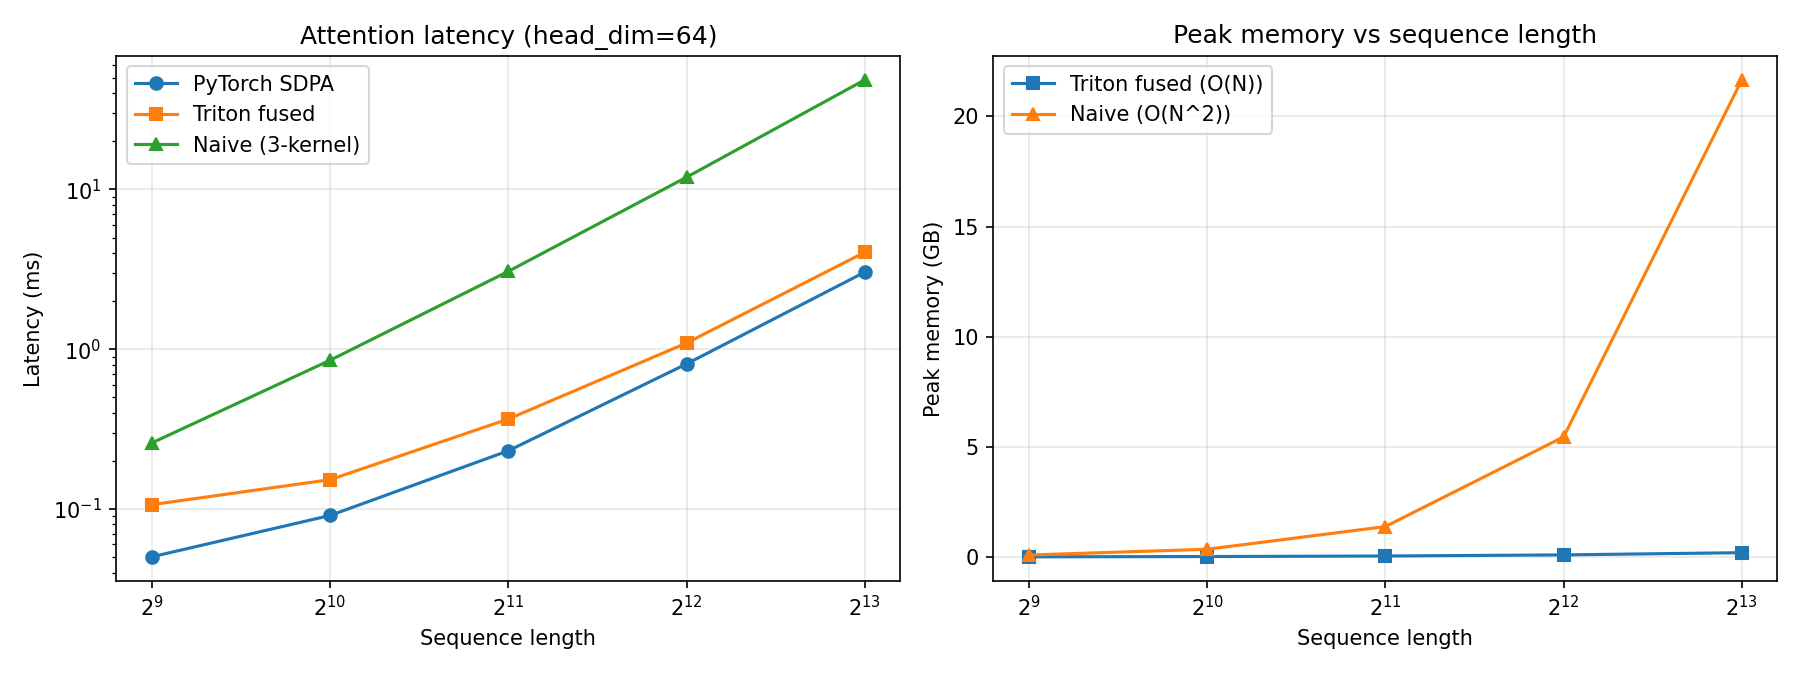

results/charts/gemm_comparison.png


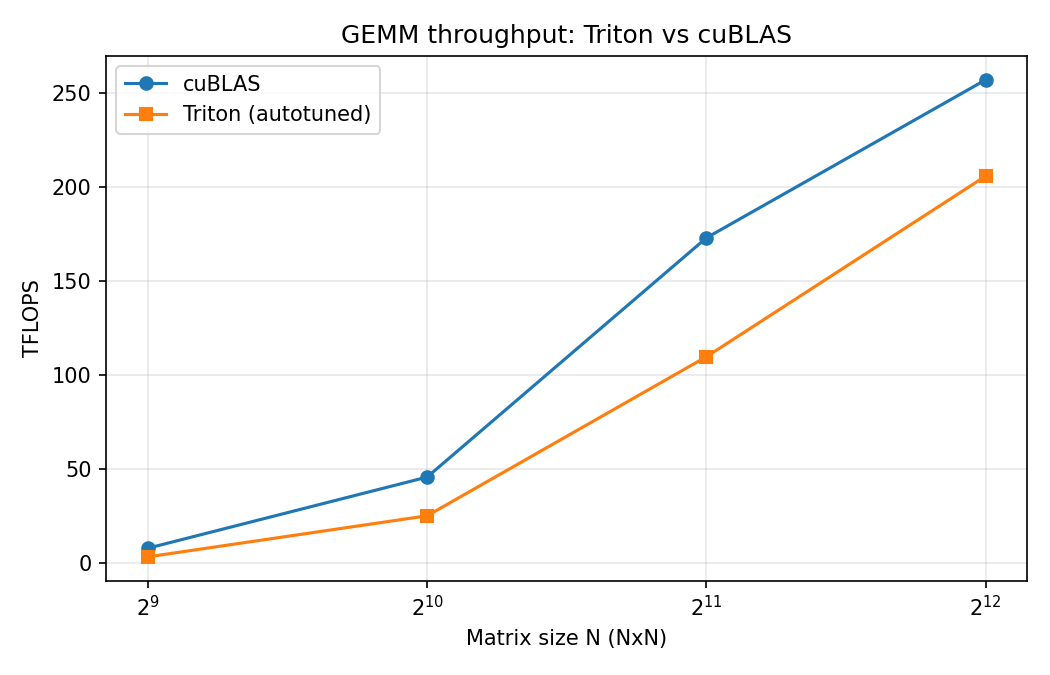

results/charts/performance_surface.png


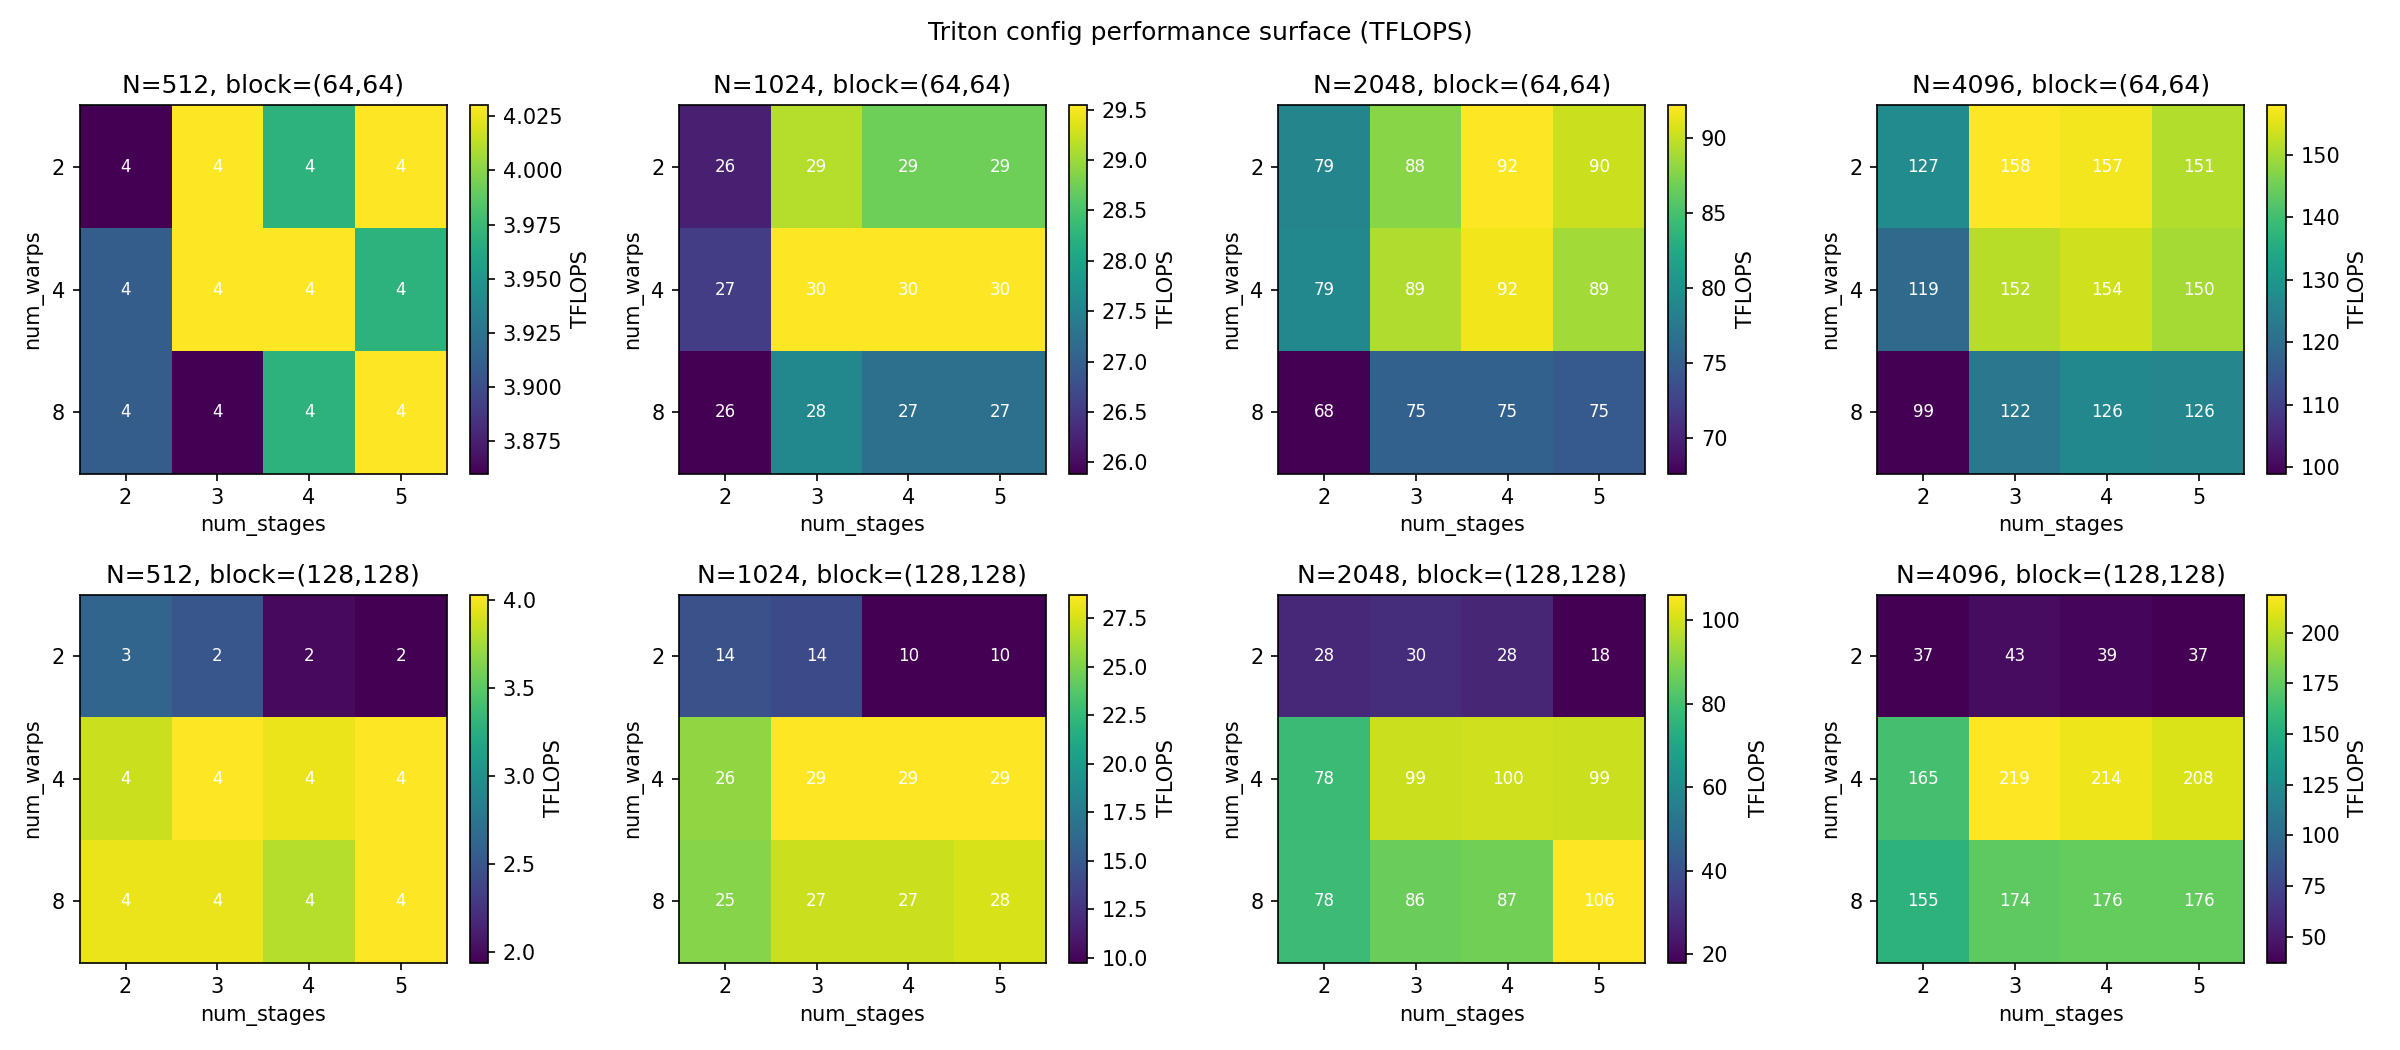

In [8]:
!python -m analysis.plots
from IPython.display import Image, display
import glob
for png in sorted(glob.glob('results/charts/*.png')):
    print(png)
    display(Image(png))

## Week 8 (part 2) — Custom ops + torch.compile

Registers the Triton kernels as PyTorch custom ops, checks graph breaks,
and benchmarks against Inductor `max-autotune`.

In [9]:
!python -m analysis.torch_compile_check

Device:
  name: NVIDIA A100-SXM4-40GB
  sm: sm_80
  sm_count: 108
  memory_gb: 42.4
  torch: 2.11.0+cu128
  cuda: 12.8

=== Graph break check ===
graph breaks: 0
graphs captured: 1

=== Benchmark vs Inductor ===
E0718 18:26:36.060000 4182 torch/_inductor/select_algorithm.py:3541] [0/0] Exception No valid triton configs. OutOfMemoryError: out of resource: triton_mm Required: 196608 Hardware limit:166912 Reducing block sizes or `num_stages` may help. for benchmark choice TritonTemplateCaller(/tmp/torchinductor_root/qq/cqqm76wvf54n3ee3zkjty33izd5vagtc2loif6ees7xsbu5bi2xo.py, ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=128, BLOCK_M=128, BLOCK_N=128, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=8)
E0718 18:26:36.060000 4182 torch/_inductor/select_algorithm.py:3541] [0/0] Traceback (most recent call last):
E0718 18:26:36.060000 4182 torch/_inductor/select_algorithm.py:3541] [0/0]   File "/usr/lib/python3.12/concurrent/futures/thread.py", line 59, in run
E0718 18

## Save results before the session dies

Colab sessions reset — persist `results/` to Drive (or `git add` + push) every run.

In [10]:
# If working from a git clone rather than Drive:
# !git add results/ && git commit -m 'sweep results $(date +%F)' && git push

# If not using git from Colab, copy to Drive:
# !cp -r results /content/drive/MyDrive/triton-kernel-comparison-results